# Toy DAG demo

Four `Source` artifacts (real Project Gutenberg texts) feeding a `Tokenizer`
trained on all of them, then a `TokenizedSource` for `odyssey`. The tokenizer
job and tokenize job both take their inputs from `refs()` -- nothing about
"which sources feed the tokenizer" is declared on the job itself.

In [1]:
from pathlib import Path

from artifact import Source, Tokenizer, TokenizedSource
from resolve import job_list, resolve, run_all
from visualizer import visualize

root = Path("../data_demo")  # kept separate from the real /data tree

In [2]:
odyssey = Source(name="odyssey", url="https://www.gutenberg.org/cache/epub/1727/pg1727.txt")
mobydick = Source(name="mobydick", url="https://www.gutenberg.org/cache/epub/2701/pg2701.txt")
romeojuliet = Source(name="romeojuliet", url="https://www.gutenberg.org/cache/epub/1513/pg1513.txt")
montecristo = Source(name="montecristo", url="https://www.gutenberg.org/cache/epub/1184/pg1184.txt")

In [3]:
tokenizer = Tokenizer(
    vocab_size=50,
    special_tokens=("<pad>", "<unk>"),
    sources=(odyssey, mobydick, montecristo),
)
tokenized_romeojuliet = TokenizedSource(tokenizer=tokenizer, source=romeojuliet)

manifest = resolve(tokenized_romeojuliet)
[job.outputs[0].relpath() for job in job_list(manifest)]  # SourceJob x4 -> TokenizerJob -> TokenizeSourceJob

[PosixPath('odyssey/body.txt'),
 PosixPath('mobydick/body.txt'),
 PosixPath('montecristo/body.txt'),
 PosixPath('tokenizers/bpe-50-39d5d50777/tokenizer.json'),
 PosixPath('romeojuliet/body.txt'),
 PosixPath('tokenizers/bpe-50-39d5d50777/bin/romeojuliet.bin')]

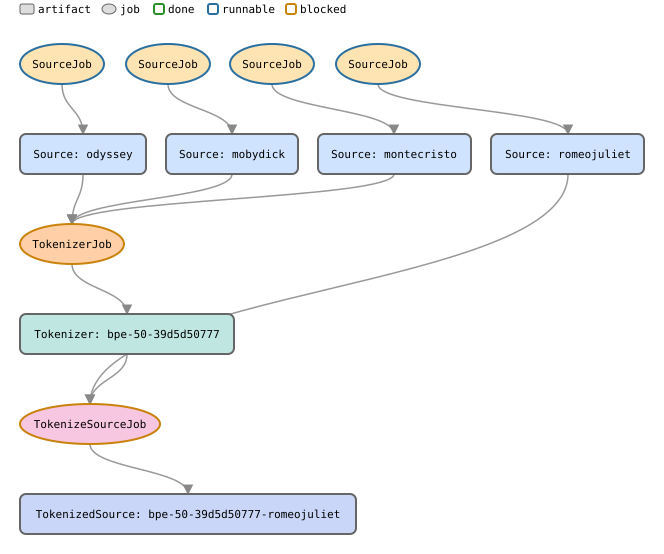

In [4]:
visualize(manifest, root)  # boxes = artifacts, ellipses = jobs; outline = status

In [5]:
run_all(tokenized_romeojuliet, root)  # downloads both sources, fits the tokenizer, then encodes odyssey
print(tokenizer.path(root).read_text())

run   odyssey/body.txt
run   mobydick/body.txt
run   montecristo/body.txt
run   tokenizers/bpe-50-39d5d50777/tokenizer.json
run   romeojuliet/body.txt
run   tokenizers/bpe-50-39d5d50777/bin/romeojuliet.bin
{
  "kind": "bpe",
  "vocab_size": 50,
  "special_tokens": [
    "<pad>",
    "<unk>"
  ],
  "trained_on": [
    "odyssey",
    "mobydick",
    "montecristo"
  ],
  "vocab": [
    "#1184]",
    "#1727]",
    "#2701]",
    "#516,",
    "$2,600,000",
    "$20,000,000!",
    "$5,000)",
    "$7,000,000.",
    "&",
    "&c.",
    "($1",
    "(1)",
    "(1535-1598).",
    "(1748-1825).",
    "(1773-1844).",
    "(1775)",
    "(1800-1876).",
    "(1897)",
    "(1900)",
    "(2)",
    "(862)",
    "(Ahab\u2019s)",
    "(Albatross)",
    "(Albert",
    "(American)",
    "(Bunger,",
    "(Don",
    "(Fac",
    "(Fife)",
    "(Footnote",
    "(Franz)",
    "(Greenland",
    "(I",
    "(Monte",
    "(Pig-fish",
    "(Pull,",
    "(Sperm",
    "(Spring,",
    "(Steelkilt)",
    "(Steelkilt\u2019s

-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -

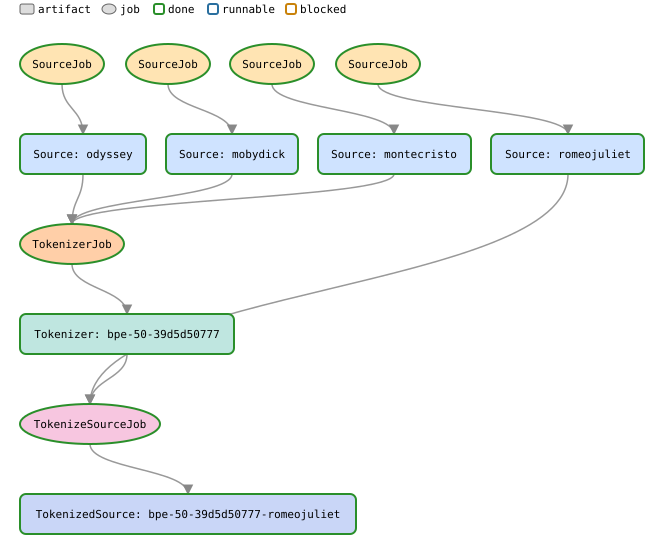

In [8]:
print(tokenized_romeojuliet.path(root).read_text())  # mock token ids for odyssey/body.txt
visualize(manifest, root)  # all green now